# Industrial Binary Classification with Heights

This notebook retrains and evaluates the industrial binary classifier after adding LoD2 building-height features.

**Input**
- Preprocessed industrial classification data with height features.
- Previously optimized model parameters and selected features.

**Output**
- Evaluated height-enhanced model and final trained classifier.

In [4]:
# Imports & Config

import numpy as np
import pandas as pd
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedShuffleSplit


import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)

ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
ML_DIR    = os.path.join(ROOT_DIR, 'data', 'ml_ready')
MODEL_DIR = os.path.join(ROOT_DIR, 'data', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Which hierarchical level to train — change this one line to switch levels
# Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'
LEVEL = 'l1b_ind_binary'

print(f"Training level: {LEVEL}")

Training level: l1b_ind_binary


In [5]:
EXPERIMENT="with_lod2_height"

HEIGHT_FEATURES=[
    "lod2_height_m",
    ]

# Correct height-specific files
train_path=os.path.join(ML_DIR,f"{LEVEL}_train_raw_height.pkl")
val_path=os.path.join(ML_DIR,f"{LEVEL}_val_raw_height.pkl")
test_path=os.path.join(ML_DIR,f"{LEVEL}_test_raw_height.pkl")
classes_path=os.path.join(ML_DIR,f"{LEVEL}_classes_height.pkl")

for path in [train_path,val_path,test_path,classes_path]:
    if not os.path.exists(path): raise FileNotFoundError(path)
    print(f"Found: {path}")

X_train_raw,y_train=joblib.load(train_path)
X_val_raw,y_val=joblib.load(val_path)
X_test_raw,y_test=joblib.load(test_path)
classes=joblib.load(classes_path)
n_classes = len(np.unique(y_train))

print("\nRaw height-split shapes:")
print(f"Train: {X_train_raw.shape}")
print(f"Val  : {X_val_raw.shape}")
print(f"Test : {X_test_raw.shape}")

print("\nHeight columns actually present:")
for col in HEIGHT_FEATURES:
    print(f"{col:<30}: train={col in X_train_raw.columns}, val={col in X_val_raw.columns}, test={col in X_test_raw.columns}")

missing={
    split:[c for c in HEIGHT_FEATURES if c not in X.columns]
    for split,X in [("train",X_train_raw),("val",X_val_raw),("test",X_test_raw)]
}
missing={k:v for k,v in missing.items() if v}

if missing:
    raise KeyError(
        f"Height files exist but do not contain the height columns: {missing}. "
        "Rerun the split-building and saving cells in the height preprocessing notebook."
    )

print("\nTrain height summary:")
display(X_train_raw[HEIGHT_FEATURES].describe().T)

Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l1b_ind_binary_train_raw_height.pkl
Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l1b_ind_binary_val_raw_height.pkl
Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l1b_ind_binary_test_raw_height.pkl
Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l1b_ind_binary_classes_height.pkl

Raw height-split shapes:
Train: (1171583, 111)
Val  : (68917, 111)
Test : (137833, 111)

Height columns actually present:
lod2_height_m                 : train=True, val=True, test=True

Train height summary:


,count,mean,std,min,25%,50%,75%,max
lod2_height_m,1030912.0,9.307855,6.123306,0.002,5.532,8.042,11.227,278.801


In [6]:
SELECTED_FEATURE_PATH=os.path.join(MODEL_DIR,f"{LEVEL}_feature_cols.pkl")

if not os.path.exists(SELECTED_FEATURE_PATH):
    raise FileNotFoundError(
        f"Previously selected feature list not found:\n{SELECTED_FEATURE_PATH}")

selected_features=list(joblib.load(SELECTED_FEATURE_PATH))

# Append the four LoD2 features without repeating any existing feature
feature_cols=list(dict.fromkeys(selected_features+HEIGHT_FEATURES))

print("\nFeature configuration:")
print(f"Previously selected features: {len(selected_features)}")
print(f"LoD2 features requested      : {len(HEIGHT_FEATURES)}")
print(f"Final model features         : {len(feature_cols)}")

# Check that every required feature exists in every split
split_frames={"train":X_train_raw, "validation":X_val_raw, "test":X_test_raw}

missing_by_split={
    split:[column for column in feature_cols if column not in frame.columns]
    for split,frame in split_frames.items()}

missing_by_split={split:columns for split,columns in missing_by_split.items() if columns}

if missing_by_split:
    for split,columns in missing_by_split.items():
        print(f"\nMissing from {split}:")
        print(columns)

    raise KeyError(
        "The raw ML split files do not contain all selected and LoD2 features. "
        "Rerun ML preprocessing after creating the height features.")

print("\nLoD2 features included:")
for column in HEIGHT_FEATURES:
    print(f"  {column}")


Feature configuration:
Previously selected features: 68
LoD2 features requested      : 1
Final model features         : 69

LoD2 features included:
  lod2_height_m


In [7]:
# Reduce the data strictly to selected features + height features
# ---------------------------------------------------------------------
X_train=X_train_raw[feature_cols].copy()
X_val=X_val_raw[feature_cols].copy()
X_test=X_test_raw[feature_cols].copy()



for column in HEIGHT_FEATURES[1:]:
    X_train[column]=X_train[column].astype("float32")
    X_val[column]=X_val[column].astype("float32")
    X_test[column]=X_test[column].astype("float32")

print("\nFinal datasets:")
print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")


# Save the augmented feature list separately; do not overwrite the baseline
HEIGHT_FEATURE_PATH=os.path.join(
    MODEL_DIR,
    f"{LEVEL}_feature_cols_{EXPERIMENT}.pkl"
)
joblib.dump(feature_cols,HEIGHT_FEATURE_PATH)


Final datasets:
X_train: (1171583, 69)
X_val  : (68917, 69)
X_test : (137833, 69)


['/fast/home/o-olajuyigbe/osm_project/data/models/l1b_ind_binary_feature_cols_with_lod2_height.pkl']

In [8]:
# Evaluation Helper (used by every model)

def evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, level, threshold=0.5):
    results = {}
    for split_name, X_sp, y_sp in [('val', X_val, y_val), ('test', X_test, y_test)]:
        
        # Apply custom decision threshold to prediction probabilities
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_sp)[:, 1]
            y_pred = (y_prob >= threshold).astype(int)
        else:
            y_pred = model.predict(X_sp).astype(int)

        report = classification_report(y_sp, y_pred, target_names=classes, output_dict=True)
        macro_f1 = f1_score(y_sp, y_pred, average='macro')
        weighted_f1 = f1_score(y_sp, y_pred, average='weighted')
        

        results[split_name] = {
            'macro_f1'   : round(macro_f1, 4),
            'weighted_f1': round(weighted_f1, 4),
            'report'     : report,
            'threshold'  : round(threshold, 3)
        }
        print(f"\n{model_name} — {split_name.upper()} (Decision Threshold: {threshold:.3f})")
        print(f"  Macro F1    : {macro_f1:.4f}")
        print(f"  Weighted F1 : {weighted_f1:.4f}")
        print(classification_report(y_sp, y_pred, target_names=classes, digits=4))

    # Confusion matrix on test using optimized threshold
    if hasattr(model, "predict_proba"):
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_pred_test = (y_prob_test >= threshold).astype(int)
    else:
        y_pred_test = model.predict(X_test).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes-1)))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_confusion.png'), dpi=150)
    plt.show()

    return results


all_results = {}  # accumulates results from all models for comparison

In [9]:
# Load the Optuna parameters saved by the original notebook
OPTUNA_PATH=os.path.join(
    MODEL_DIR,
    f"{LEVEL}_best_hyperparameters.json")

if not os.path.exists(OPTUNA_PATH):
    raise FileNotFoundError(
        f"Saved Optuna parameters not found:\n{OPTUNA_PATH}")

with open(OPTUNA_PATH,"r") as file:
    saved_optuna=json.load(file)

best_lgb_params=saved_optuna["lightgbm"].copy()
best_xgb_params=saved_optuna["xgboost"].copy()

print("\nSaved Optuna parameters loaded:")
print("\nLightGBM:")
print(best_lgb_params)
print("\nXGBoost:")
print(best_xgb_params)


Saved Optuna parameters loaded:

LightGBM:
{'learning_rate': 0.06730352532559565, 'num_leaves': 179, 'min_child_samples': 188, 'subsample': 0.7900442061744407, 'colsample_bytree': 0.7592481637854478, 'scale_pos_weight': 4.179003417380271, 'reg_alpha': 0.0024530988402639608, 'reg_lambda': 0.03749792947518052, 'min_split_gain': 0.004642435369933202}

XGBoost:
{'learning_rate': 0.03456373518935789, 'max_depth': 11, 'subsample': 0.791244288521994, 'colsample_bytree': 0.7873957189071564, 'scale_pos_weight': 5.05333222140778, 'alpha': 0.010895317041004172, 'lambda': 0.33440809630976165, 'gamma': 0.007270716860000048, 'min_child_weight': 10}


In [10]:

# Define full dataset model using optimized configurations
FINAL_CONFIGS = {
    'lightgbm': {
        'cls': lgb.LGBMClassifier,
        'params': {
            'objective': 'binary', 'metric': 'binary_logloss', 'boosting_type': 'gbdt',
            'n_estimators': 25000, 'importance_type': 'gain',
            'n_jobs': -1, 'random_state': 42, 'verbosity': -1, **best_lgb_params, 'max_depth': -1
        },
        'fit_kwargs': {'eval_set': [(X_val, y_val)], 'callbacks': [lgb.early_stopping(150), lgb.log_evaluation(200)]}
    },
    'xgboost': {
        'cls': xgb.XGBClassifier,
        'params': {
            'objective': 'binary:logistic', 'eval_metric': 'logloss',
            'n_estimators': 25000, 'tree_method': 'hist', 'importance_type': 'gain',
            'early_stopping_rounds': 150, 'n_jobs': -1, 'random_state': 42, **best_xgb_params
        },
        'fit_kwargs': {'eval_set': [(X_val, y_val)], 'verbose': 200}
    }
}

trained_models = {}

for model_name, cfg in FINAL_CONFIGS.items():
    print(f"\n{'='*60}\nTraining finalized {model_name.upper()} on 100% data...\n{'='*60}")
    
    model = cfg['cls'](**cfg['params'])
    model.fit(X_train, y_train, **cfg['fit_kwargs'])
    
    # Save the native, raw model 
    save_path = os.path.join(MODEL_DIR, f'{LEVEL}_{model_name}_optimized_height.pkl')
    joblib.dump(model, save_path)
    trained_models[model_name] = model
    print(f"Saved base model pipeline → {save_path}")


Training finalized LIGHTGBM on 100% data...
Training until validation scores don't improve for 150 rounds
[200]	valid_0's binary_logloss: 0.360111
[400]	valid_0's binary_logloss: 0.341082
[600]	valid_0's binary_logloss: 0.325687
[800]	valid_0's binary_logloss: 0.311761
[1000]	valid_0's binary_logloss: 0.301301
[1200]	valid_0's binary_logloss: 0.292689
[1400]	valid_0's binary_logloss: 0.285166
[1600]	valid_0's binary_logloss: 0.278661
[1800]	valid_0's binary_logloss: 0.273314
[2000]	valid_0's binary_logloss: 0.268108
[2200]	valid_0's binary_logloss: 0.263829
[2400]	valid_0's binary_logloss: 0.260024
[2600]	valid_0's binary_logloss: 0.256619
[2800]	valid_0's binary_logloss: 0.253537
[3000]	valid_0's binary_logloss: 0.250605
[3200]	valid_0's binary_logloss: 0.247929
[3400]	valid_0's binary_logloss: 0.245687
[3600]	valid_0's binary_logloss: 0.243691
[3800]	valid_0's binary_logloss: 0.241991
[4000]	valid_0's binary_logloss: 0.240154
[4200]	valid_0's binary_logloss: 0.238545
[4400]	valid_0'


BASELINE TEST SET EVALUATION (Default 0.5 Threshold)

lightgbm — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.8741
  Weighted F1 : 0.9137
                precision    recall  f1-score   support

non_industrial     0.9462    0.9429    0.9445     53831
    industrial     0.7987    0.8086    0.8036     15086

      accuracy                         0.9135     68917
     macro avg     0.8725    0.8758    0.8741     68917
  weighted avg     0.9139    0.9135    0.9137     68917


lightgbm — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8710
  Weighted F1 : 0.9116
                precision    recall  f1-score   support

non_industrial     0.9449    0.9414    0.9432    107660
    industrial     0.7937    0.8042    0.7989     30173

      accuracy                         0.9114    137833
     macro avg     0.8693    0.8728    0.8710    137833
  weighted avg     0.9118    0.9114    0.9116    137833



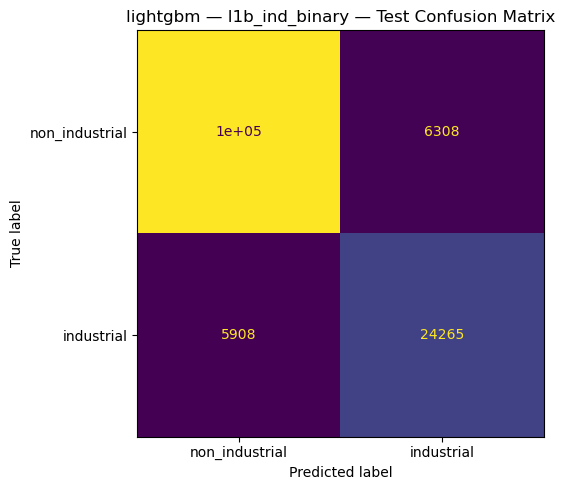


xgboost — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.8754
  Weighted F1 : 0.9145
                precision    recall  f1-score   support

non_industrial     0.9475    0.9424    0.9449     53831
    industrial     0.7983    0.8135    0.8058     15086

      accuracy                         0.9142     68917
     macro avg     0.8729    0.8780    0.8754     68917
  weighted avg     0.9148    0.9142    0.9145     68917


xgboost — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8728
  Weighted F1 : 0.9126
                precision    recall  f1-score   support

non_industrial     0.9468    0.9406    0.9437    107660
    industrial     0.7928    0.8113    0.8019     30173

      accuracy                         0.9123    137833
     macro avg     0.8698    0.8759    0.8728    137833
  weighted avg     0.9131    0.9123    0.9126    137833



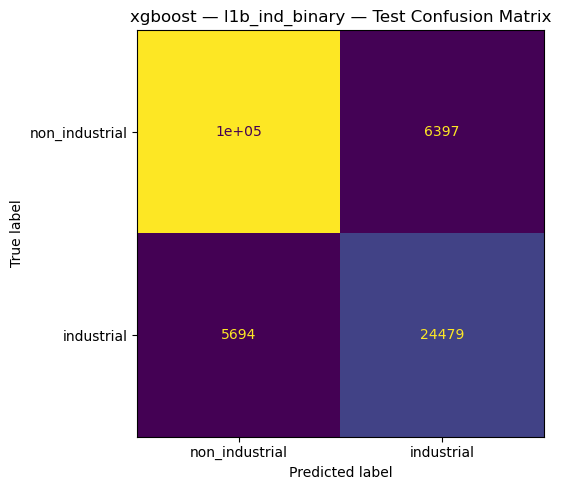

In [11]:
print(f"\n{'='*60}\nBASELINE TEST SET EVALUATION (Default 0.5 Threshold)\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL, threshold=0.5)


BASELINE TEST SET EVALUATION (Default 0.5 Threshold)

lightgbm — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.8741
  Weighted F1 : 0.9137
                precision    recall  f1-score   support

non_industrial     0.9462    0.9429    0.9445     53831
    industrial     0.7987    0.8086    0.8036     15086

      accuracy                         0.9135     68917
     macro avg     0.8725    0.8758    0.8741     68917
  weighted avg     0.9139    0.9135    0.9137     68917


lightgbm — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8710
  Weighted F1 : 0.9116
                precision    recall  f1-score   support

non_industrial     0.9449    0.9414    0.9432    107660
    industrial     0.7937    0.8042    0.7989     30173

      accuracy                         0.9114    137833
     macro avg     0.8693    0.8728    0.8710    137833
  weighted avg     0.9118    0.9114    0.9116    137833



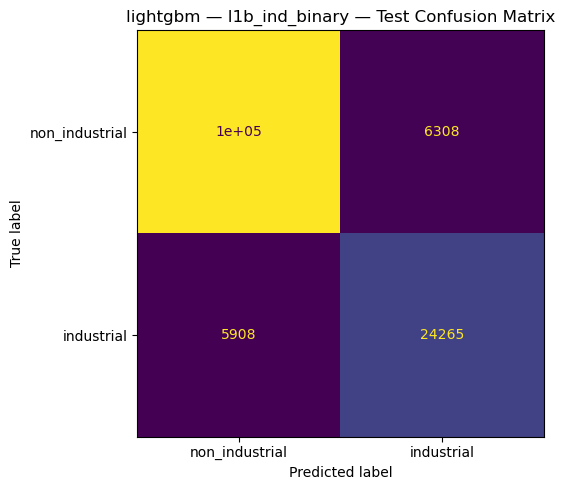


xgboost — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.8754
  Weighted F1 : 0.9145
                precision    recall  f1-score   support

non_industrial     0.9475    0.9424    0.9449     53831
    industrial     0.7983    0.8135    0.8058     15086

      accuracy                         0.9142     68917
     macro avg     0.8729    0.8780    0.8754     68917
  weighted avg     0.9148    0.9142    0.9145     68917


xgboost — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8728
  Weighted F1 : 0.9126
                precision    recall  f1-score   support

non_industrial     0.9468    0.9406    0.9437    107660
    industrial     0.7928    0.8113    0.8019     30173

      accuracy                         0.9123    137833
     macro avg     0.8698    0.8759    0.8728    137833
  weighted avg     0.9131    0.9123    0.9126    137833



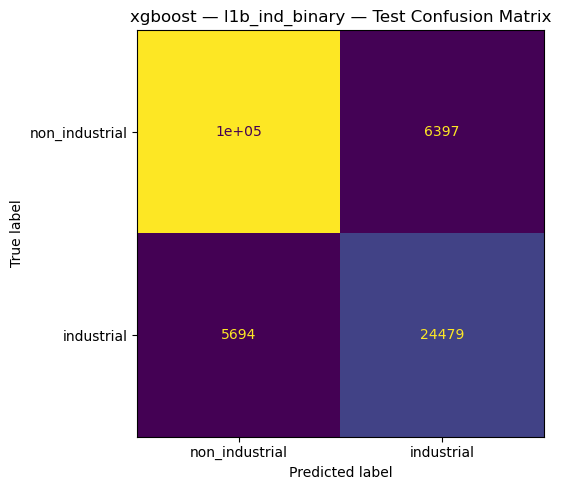

In [12]:
print(f"\n{'='*60}\nBASELINE TEST SET EVALUATION (Default 0.5 Threshold)\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL, threshold=0.5)

In [13]:
for model_name, cfg in FINAL_CONFIGS.items():
    print(f"\n{'='*60}\nTraining finalized {model_name.upper()} on 100% data...\n{'='*60}")
    
    model = cfg['cls'](**cfg['params'])
    model.fit(X_train, y_train, **cfg['fit_kwargs'])
    
    # Save the native, raw model 
    save_path = os.path.join(MODEL_DIR, f'{LEVEL}_{model_name}_optimized_height.pkl')
    joblib.dump(model, save_path)
    trained_models[model_name] = model
    print(f"Saved base model pipeline → {save_path}")


Training finalized LIGHTGBM on 100% data...
Training until validation scores don't improve for 150 rounds
[200]	valid_0's binary_logloss: 0.360111
[400]	valid_0's binary_logloss: 0.341082
[600]	valid_0's binary_logloss: 0.325687
[800]	valid_0's binary_logloss: 0.311761
[1000]	valid_0's binary_logloss: 0.301301
[1200]	valid_0's binary_logloss: 0.292689
[1400]	valid_0's binary_logloss: 0.285166
[1600]	valid_0's binary_logloss: 0.278661
[1800]	valid_0's binary_logloss: 0.273314
[2000]	valid_0's binary_logloss: 0.268108
[2200]	valid_0's binary_logloss: 0.263829
[2400]	valid_0's binary_logloss: 0.260024
[2600]	valid_0's binary_logloss: 0.256619
[2800]	valid_0's binary_logloss: 0.253537
[3000]	valid_0's binary_logloss: 0.250605
[3200]	valid_0's binary_logloss: 0.247929
[3400]	valid_0's binary_logloss: 0.245687
[3600]	valid_0's binary_logloss: 0.243691
[3800]	valid_0's binary_logloss: 0.241991
[4000]	valid_0's binary_logloss: 0.240154
[4200]	valid_0's binary_logloss: 0.238545
[4400]	valid_0'

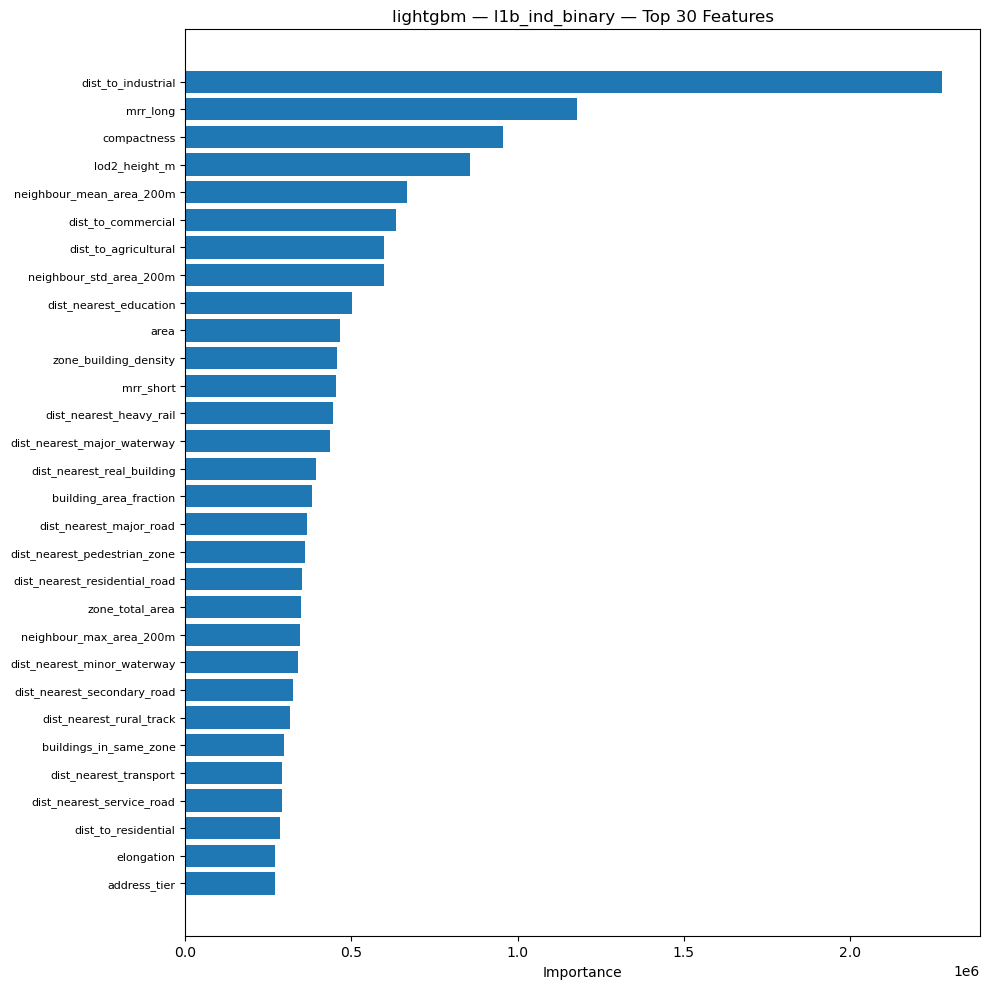

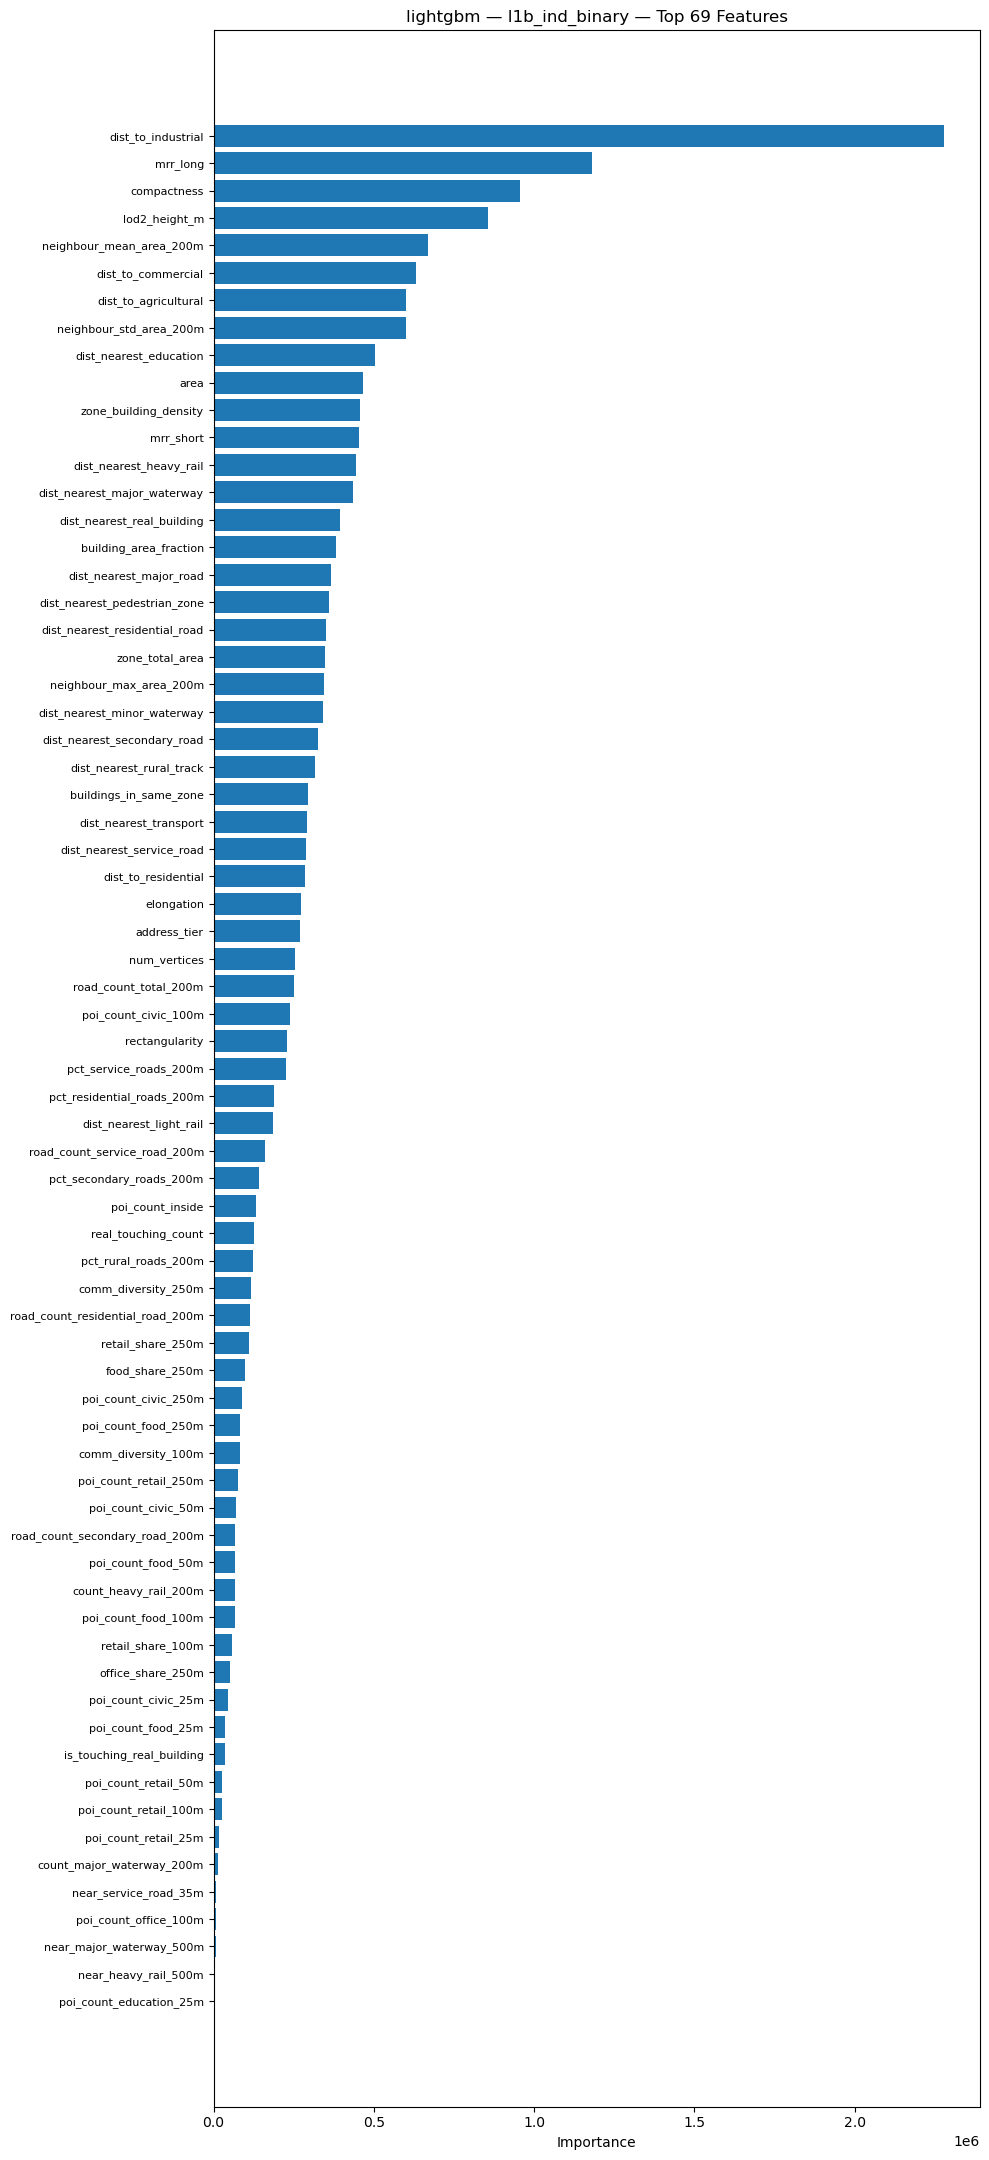

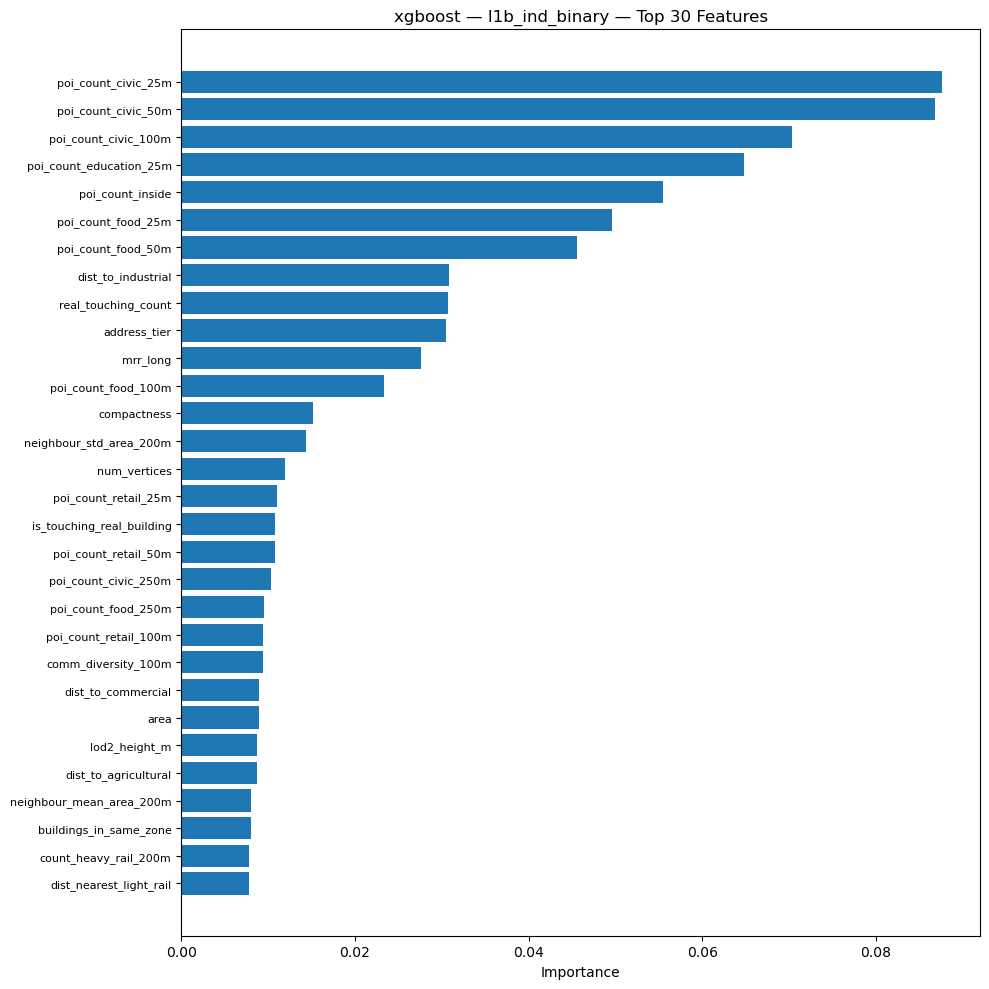

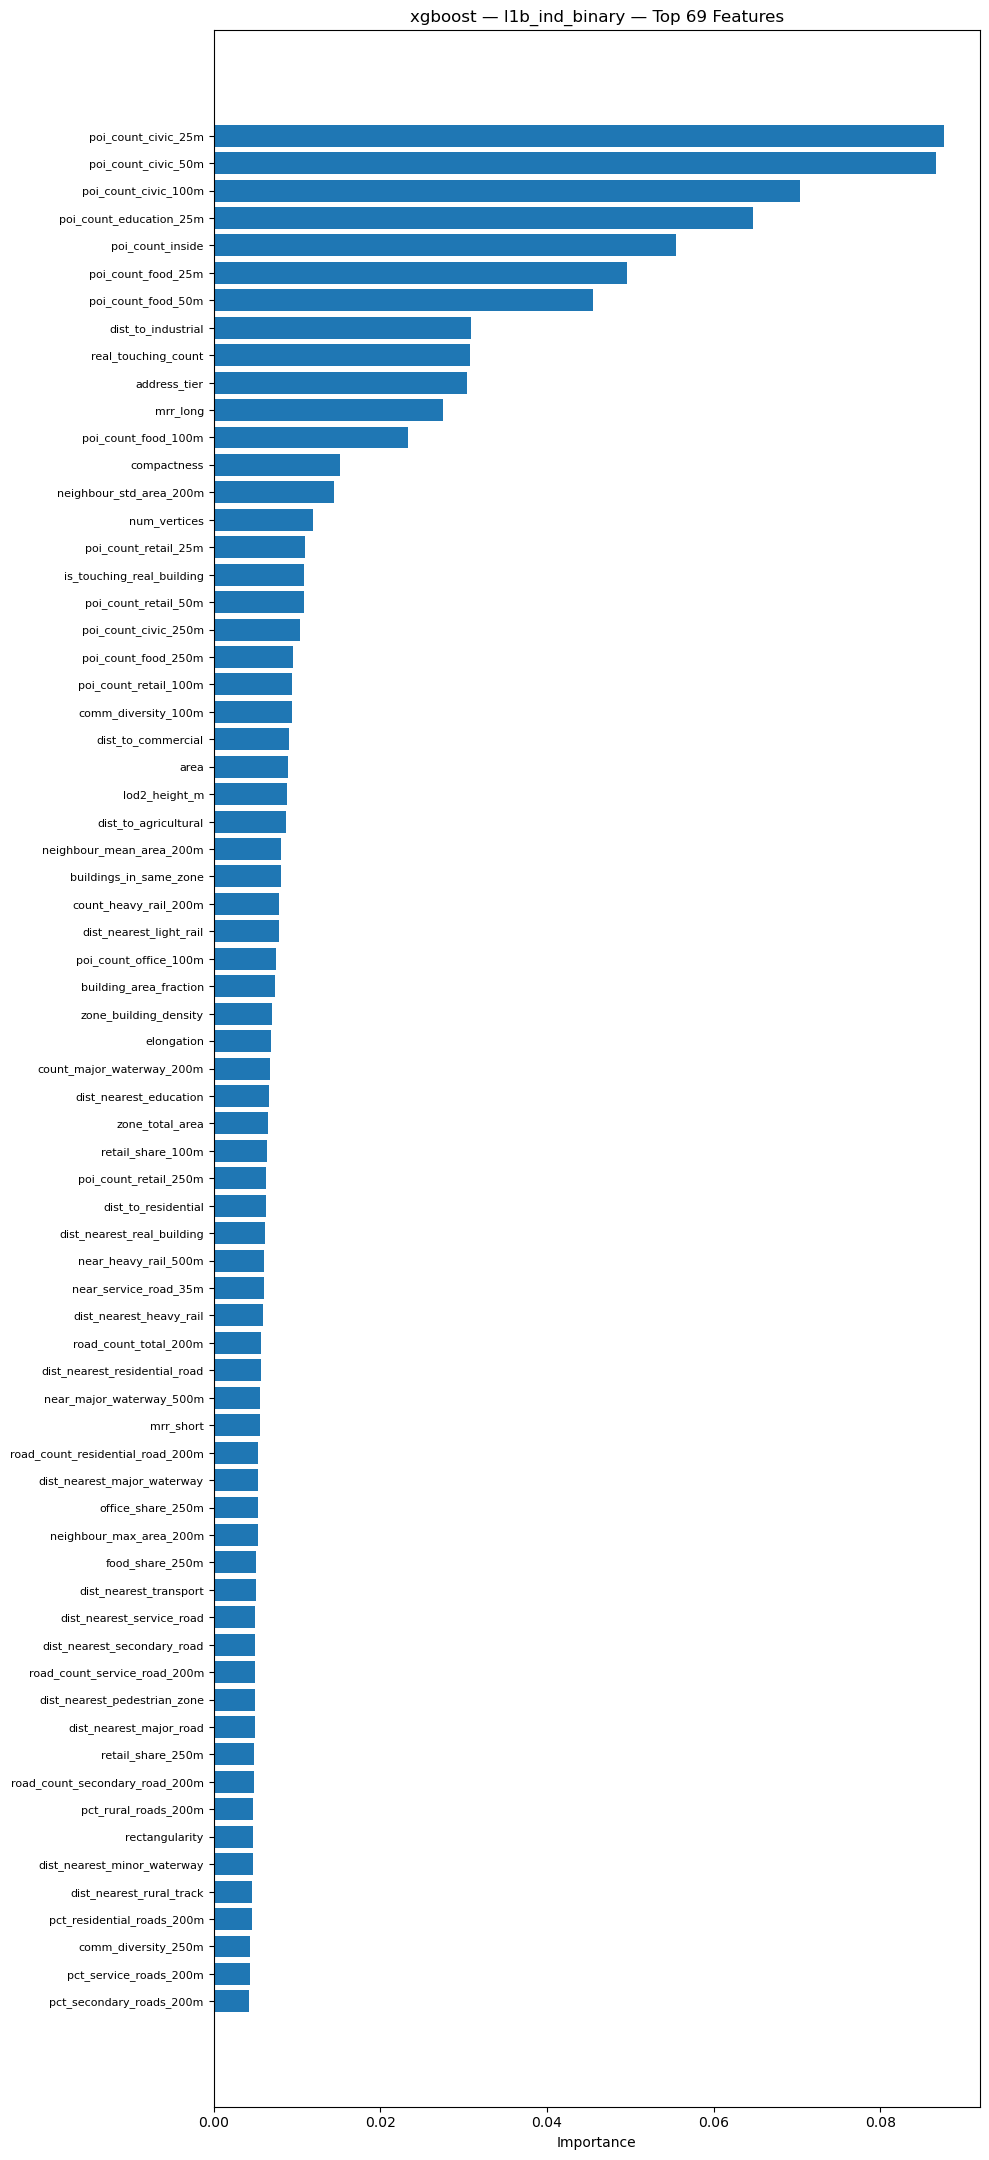

In [14]:
# =====================================================================
# CELL 6 — Feature Importance (trees only)
# =====================================================================
def plot_feature_importance(model, model_name, feature_cols, level, top_n=30):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        return

    idx  = np.argsort(imp)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, top_n * 0.3 + 1))
    ax.barh(range(top_n), imp[idx][::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_cols[i] for i in idx[::-1]], fontsize=8)
    ax.set_title(f'{model_name} — {level} — Top {top_n} Features')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_importance.png'), dpi=120)
    plt.show()

for model_name, model in trained_models.items():
    plot_feature_importance(model, model_name, feature_cols, LEVEL)
    plot_feature_importance(model, model_name, feature_cols, LEVEL, len(feature_cols))

In [15]:
#  Compare All Models on This Level
# 
print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)

for model_name, res in all_results.items():
    mf1 = res['test']['macro_f1']
    wf1 = res['test']['weighted_f1']
    print(f"{model_name:<20} {mf1:>10.4f} {wf1:>13.4f}")

# Save results to JSON for later aggregation
results_path = os.path.join(MODEL_DIR, f'{LEVEL}_results_height.json')
# Make results JSON-serialisable
serialisable = {
    m: {s: {k: v for k, v in r.items() if k != 'report'}
        for s, r in res.items()}
    for m, res in all_results.items()
}
with open(results_path, 'w') as f:
    json.dump(serialisable, f, indent=2)
print(f"\nResults saved → {results_path}")


MODEL COMPARISON — l1b_ind_binary — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.8710        0.9116
xgboost                  0.8728        0.9126

Results saved → /fast/home/o-olajuyigbe/osm_project/data/models/l1b_ind_binary_results_height.json


In [16]:
# Production Retraining (Train + Test) ONLY for the Winning Model

BEST_MODEL = 'xgboost'  

print(f"Preparing final production rollout strictly for the winning model: {BEST_MODEL.upper()}")

# Ensure all splits are DataFrames with the same ordered features
def ensure_feature_dataframe(X,feature_cols):
    if isinstance(X,pd.DataFrame):
        return X[feature_cols].copy()
    return pd.DataFrame(X,columns=feature_cols)

X_train_df=ensure_feature_dataframe(X_train,feature_cols)
X_val_df=ensure_feature_dataframe(X_val,feature_cols)
X_test_df=ensure_feature_dataframe(X_test,feature_cols)

if list(X_train_df.columns)!=list(X_val_df.columns):
    raise ValueError("Train and validation features are not aligned.")

if list(X_train_df.columns)!=list(X_test_df.columns):
    raise ValueError("Train and test features are not aligned.")

# Train + test = 95% production-training pool
X_production_train=pd.concat(
    [X_train_df,X_test_df],
    axis=0,
    ignore_index=True
)

y_production_train=np.concatenate([y_train,y_test])

# Keep validation as the early-stopping set
X_production_val=X_val_df
y_production_val = y_val

print(f"Expanded Training Pool Size : {X_production_train.shape[0]:,} rows (95%)")
print(f"Early Stopping Validation Size: {X_production_val.shape[0]:,} rows (5%)")

# 3. Dynamically load the correct architecture configurations and parameters
if BEST_MODEL == 'lightgbm':
    print("Configuring final LightGBM pipeline...")
    prod_model = lgb.LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        boosting_type='gbdt',
        n_estimators=25000, 
        importance_type='gain',
        n_jobs=-1,
        random_state=42,
        verbosity=-1,
        **best_lgb_params,
        max_depth=-1
    )
    fit_kwargs = {
        'eval_set': [(X_production_val, y_production_val)],
        'callbacks': [lgb.early_stopping(150), lgb.log_evaluation(200)]
    }
    
elif BEST_MODEL == 'xgboost':
    print("Configuring final XGBoost pipeline...")
    prod_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=25000, 
        tree_method='hist',
        early_stopping_rounds=150,
        n_jobs=-1, importance_type='gain',
        random_state=42,
        **best_xgb_params  # Automatically injects your optimized parameters from Cell 4
    )
    fit_kwargs = {
        'eval_set': [(X_production_val, y_production_val)],
        'verbose': 200
    }
else:
    raise ValueError("Invalid BEST_MODEL name. Please enter either 'lightgbm' or 'xgboost'.")

print(f"\nRetraining {BEST_MODEL.upper()} on 95% of your dataset...")
prod_model.fit(X_production_train, y_production_train, **fit_kwargs)

production_save_path = os.path.join(MODEL_DIR, f'{LEVEL}_xgb_PRODUCTION_FINAL_height.pkl')
joblib.dump(prod_model, production_save_path)

print(f"\n{'='*60}")
print(f"   Saved model to: {production_save_path}")
print(f"{'='*60}")

Preparing final production rollout strictly for the winning model: XGBOOST
Expanded Training Pool Size : 1,309,416 rows (95%)
Early Stopping Validation Size: 68,917 rows (5%)
Configuring final XGBoost pipeline...

Retraining XGBOOST on 95% of your dataset...
[0]	validation_0-logloss:0.78515
[200]	validation_0-logloss:0.38570
[400]	validation_0-logloss:0.35917
[600]	validation_0-logloss:0.33797
[800]	validation_0-logloss:0.32011
[1000]	validation_0-logloss:0.30600
[1200]	validation_0-logloss:0.29383
[1400]	validation_0-logloss:0.28387
[1600]	validation_0-logloss:0.27493
[1800]	validation_0-logloss:0.26772
[2000]	validation_0-logloss:0.26090
[2200]	validation_0-logloss:0.25505
[2400]	validation_0-logloss:0.25013
[2600]	validation_0-logloss:0.24556
[2800]	validation_0-logloss:0.24163
[3000]	validation_0-logloss:0.23815
[3200]	validation_0-logloss:0.23518
[3400]	validation_0-logloss:0.23254
[3600]	validation_0-logloss:0.23024
[3800]	validation_0-logloss:0.22803
[4000]	validation_0-logloss: